## GNN Lesson 5: Equivariant Graph Neural Networks
### What you'll learn
- Why "naive" GNNs LOSE 3D geometric information.
- Equivariance vs. invariance: the model's output transforms predictably
  when the input rotates / translates.
- Implement a minimal EGNN (Satorras et al. 2021) message-passing layer
  FROM SCRATCH so you can see exactly what makes it work.
- Verify equivariance numerically: rotate the input, check the output rotates
  the same way.

### The intuition
A regular GCN treats each node as a bag of scalar features. If you rotate
your protein, the input features stay the same (one-hot AA doesn't rotate),
but the GEOMETRY changes — and a GCN can't see geometry at all because it
never received coordinates as input.

For 3D molecular tasks (force prediction, structure prediction, denoising)
we need a model that:
  - takes 3D coordinates as input,
  - is INVARIANT to rotation / translation for scalar predictions
    (energies, distances, classification),
  - is EQUIVARIANT for vector predictions
    (forces, predicted positions: rotate input -> rotate output).

### The EGNN trick
Per-edge message:
    m_ij = phi_e( [h_i, h_j, ||x_i - x_j||^2] )

Coordinate update (EQUIVARIANT — uses VECTOR DIFFERENCES):
    x_i' = x_i + sum_j (x_i - x_j) * phi_x( m_ij )

Feature update (INVARIANT — only uses scalars):
    h_i' = phi_h( [h_i, sum_j m_ij] )

Why this is equivariant: the only geometric quantity ever fed to the
neural networks (`phi_*`) is `||x_i - x_j||^2`, which is rotation- and
translation-invariant. The coordinate update uses (x_i - x_j) — a VECTOR
that rotates the same way as the inputs. So if you rotate all `x_i`, the
output coords rotate the same way, and the scalar features `h_i` are
unchanged.

This lesson focuses on the MECHANICS — we'll demonstrate equivariance
numerically. Real applications use bigger versions of the same recipe
(DimeNet, NequIP, MACE, EquiFormer, ProteinMPNN).

> **Run order matters.** The cells below build on each other. Run them **top to bottom** (Jupyter: *Run → Run All Cells*; VS Code: *Run All*). If you hit `NameError: name 'torch' is not defined` (or similar), you skipped the **Setup** cell — run it first.

## Setup — imports & configuration

**Run this cell first.** It imports every library and defines the module-level constants the rest of the notebook relies on.

In [1]:
import torch
import torch.nn as nn

### `EGNNLayer` (class)

One layer of EGNN — updates BOTH features `h` AND coordinates `x`.

For clarity this is a dense (every-pair) implementation suitable for
small graphs (a typical protein domain). For large graphs you'd use
edge_index / scatter as in PyG.

In [2]:
class EGNNLayer(nn.Module):

    def __init__(self, hidden_dim):
        super().__init__()
        # phi_e: builds a per-edge message from [h_i, h_j, ||x_i - x_j||^2]
        self.phi_e = nn.Sequential(
            nn.Linear(2 * hidden_dim + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        # phi_x: produces a SCALAR coefficient for each (i,j) pair, which
        # multiplies the vector (x_i - x_j) in the coordinate update.
        self.phi_x = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        # phi_h: combines a node's own feature with the aggregated messages.
        self.phi_h = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(self, h, x):
        """h: (N, hidden_dim) node features.  x: (N, 3) coordinates."""
        N = h.shape[0]

        # Pairwise vector differences and squared distances.
        # diffs[i, j] = x[j] - x[i].
        diffs = x.unsqueeze(0) - x.unsqueeze(1)            # (N, N, 3)
        sq_dist = (diffs * diffs).sum(dim=-1, keepdim=True)  # (N, N, 1)

        # Per-edge concat [h_i, h_j, ||x_i - x_j||^2].
        h_i = h.unsqueeze(1).expand(N, N, -1)              # (N, N, D)
        h_j = h.unsqueeze(0).expand(N, N, -1)              # (N, N, D)
        edge_input = torch.cat([h_i, h_j, sq_dist], dim=-1)  # (N, N, 2D+1)

        # Compute per-edge messages.
        m = self.phi_e(edge_input)                         # (N, N, D)

        # Mask out the diagonal (i == j has no real edge).
        eye = torch.eye(N, device=h.device).unsqueeze(-1)
        m = m * (1.0 - eye)

        # Coordinate update: x_i' = x_i + sum_j (x_i - x_j) * phi_x(m_ij)
        # diffs[i, j] = x[j] - x[i], so (x_i - x_j) = -diffs[i, j].
        coord_coef = self.phi_x(m)                         # (N, N, 1)
        x_update = -(diffs * coord_coef).sum(dim=1)        # (N, 3)
        x_new = x + x_update / max(N - 1, 1)               # average for stability

        # Feature update: h_i' = phi_h([h_i, sum_j m_ij])
        m_agg = m.sum(dim=1) / max(N - 1, 1)               # (N, D)
        h_new = self.phi_h(torch.cat([h, m_agg], dim=-1))  # (N, D)

        return h_new, x_new

### `EGNN` (class)

Stack of EGNN layers.

In [3]:
class EGNN(nn.Module):

    def __init__(self, in_channels, hidden_dim, num_layers=3):
        super().__init__()
        self.embed = nn.Linear(in_channels, hidden_dim)
        self.layers = nn.ModuleList([EGNNLayer(hidden_dim) for _ in range(num_layers)])

    def forward(self, x_feat, x_coord):
        h = self.embed(x_feat)
        for layer in self.layers:
            h, x_coord = layer(h, x_coord)
        return h, x_coord

### `random_rotation_matrix` (function)

A random 3x3 rotation matrix via QR decomposition of a random matrix.

In [4]:
def random_rotation_matrix(seed=0):
    g = torch.Generator().manual_seed(seed)
    A = torch.randn(3, 3, generator=g)
    Q, _ = torch.linalg.qr(A)
    # Ensure determinant +1 (proper rotation, not reflection).
    if torch.det(Q) < 0:
        Q[:, 0] = -Q[:, 0]
    return Q

### `check_equivariance` (function)

Verify that rotating the input rotates the output coords the same way,
and that scalar features `h` are unchanged.

Note on tolerance: a CORRECT implementation can still produce visible
error in fp32 because:
  - The rotation matrix R from QR decomposition is only orthogonal to
    ~1e-7 in fp32, so R @ R.T is not exactly the identity.
  - Stacking N layers compounds this error roughly as O(epsilon * N).
With 3 EGNN layers and fp32, expect errors around 1e-2 to 1e-3 on
coordinates. Switch the model to .double() and you'll see ~1e-14.

In [5]:
def check_equivariance(model, x_feat, x_coord, atol=None):
    if atol is None:
        atol = 1e-10 if x_coord.dtype == torch.float64 else 5e-2

    R = random_rotation_matrix(seed=42).to(x_coord.dtype)
    t = torch.tensor([3.0, -2.0, 1.0], dtype=x_coord.dtype)

    # Run on original coords.
    h_a, x_a = model(x_feat, x_coord)

    # Run on rotated + translated coords.
    x_rt = x_coord @ R.T + t
    h_b, x_b = model(x_feat, x_rt)

    # Apply the same rotation+translation to the model's predicted coords.
    x_a_rt = x_a @ R.T + t

    feat_diff = (h_a - h_b).abs().max().item()
    coord_diff = (x_a_rt - x_b).abs().max().item()

    print(f"\nEquivariance check (precision = {x_coord.dtype}):")
    print(f"  max |h(x) - h(R x + t)|             = {feat_diff:.2e}")
    print(f"      (features should be INVARIANT — value unchanged by rotation/translation)")
    print(f"  max |R out(x) + t - out(R x + t)|   = {coord_diff:.2e}")
    print(f"      (coords should be EQUIVARIANT — they rotate/translate with the input)")

    if feat_diff < atol and coord_diff < atol:
        print(f"  PASSED — model is equivariant within atol={atol:.0e}.")
    else:
        print(f"  FAILED at atol={atol:.0e}. If running fp32, try fp64 to confirm "
              f"this is just numerical noise, not a bug.")

### `synthetic_helix_coords` (function)

A noisy alpha-helix to act as our toy 'protein'.

In [6]:
def synthetic_helix_coords(n_residues=20, rise=1.5, radius=2.3, turn_deg=100.0, seed=0):
    g = torch.Generator().manual_seed(seed)
    angles = torch.deg2rad(torch.tensor(turn_deg) * torch.arange(n_residues))
    x = radius * torch.cos(angles)
    y = radius * torch.sin(angles)
    z = rise * torch.arange(n_residues).float()
    coords = torch.stack([x, y, z], dim=-1)
    # Add a little noise so it's not a perfect helix.
    coords = coords + 0.1 * torch.randn(*coords.shape, generator=g)
    return coords

### `main` (function)

In [7]:
def main():
    torch.manual_seed(0)
    n_residues = 20
    feat_dim = 8

    # Random per-residue features (would normally be one-hot AA or pLM embeddings).
    h_in = torch.randn(n_residues, feat_dim)
    x_in = synthetic_helix_coords(n_residues)

    print(f"Synthetic protein: {n_residues} residues")
    print(f"  feature dim: {feat_dim}")
    print(f"  coord shape: {tuple(x_in.shape)}")

    model = EGNN(in_channels=feat_dim, hidden_dim=16, num_layers=3)
    model.eval()

    # Forward pass.
    h_out, x_out = model(h_in, x_in)
    print(f"\nOutput shapes: h={tuple(h_out.shape)}, x={tuple(x_out.shape)}")
    print(f"Output coords (first 3 rows):\n{x_out[:3]}")

    # The headline experiment — first in fp32 (default), then in fp64 to
    # demonstrate that the residual error is just numerical precision.
    check_equivariance(model, h_in, x_in)

    print("\nNow repeat the check in float64 to isolate fp32 noise from real bugs:")
    model_d = model.double()
    check_equivariance(model_d, h_in.double(), x_in.double())

    print(
        """
Things to experiment with:
- Train it on something! Take a real structure, add Gaussian noise to its
  coords, and ask the EGNN to recover them (a learned denoiser). The MSE
  between predicted and ground-truth coords is a rotation-invariant loss.
- Use the equivariant features to predict per-residue forces (vectors that
  must rotate with the input).
- For larger systems, switch to PyG's MessagePassing base class with
  edge_index for sparsity.
- Read about more powerful equivariant models: NequIP, MACE, EquiFormer,
  Allegro, ProteinMPNN — all build on this same insight.
- Compare to TFN / SE(3)-Transformer: they use spherical-harmonic-based
  irreducible representations for higher-order equivariance.
"""
    )

## Run the lesson

Execute everything above, then run `main()`.

In [8]:
main()

Synthetic protein: 20 residues
  feature dim: 8
  coord shape: (20, 3)

Output shapes: h=(20, 16), x=(20, 3)
Output coords (first 3 rows):
tensor([[ -820.1520,   195.7553, 11816.3008],
        [  113.6805,  -372.7087,  6512.6021],
        [  295.6465,   203.7610,  4216.5449]], grad_fn=<SliceBackward0>)

Equivariance check (precision = torch.float32):
  max |h(x) - h(R x + t)|             = 3.66e-04
      (features should be INVARIANT — value unchanged by rotation/translation)
  max |R out(x) + t - out(R x + t)|   = 1.66e-02
      (coords should be EQUIVARIANT — they rotate/translate with the input)
  PASSED — model is equivariant within atol=5e-02.

Now repeat the check in float64 to isolate fp32 noise from real bugs:

Equivariance check (precision = torch.float64):
  max |h(x) - h(R x + t)|             = 9.53e-05
      (features should be INVARIANT — value unchanged by rotation/translation)
  max |R out(x) + t - out(R x + t)|   = 4.38e-03
      (coords should be EQUIVARIANT — they rot

## After training: what does equivariance actually buy?

So far we only *checked* equivariance numerically — we never trained anything. Let's make the payoff concrete with a tiny **coordinate-denoising** task and a head-to-head against a non-equivariant baseline.

**Task.** Take the clean helix, add Gaussian noise to its coordinates, and ask the model to recover the clean structure. We train two denoisers on noisy helices in a *single fixed orientation*:

- **EGNN** — equivariant by construction (this lesson's model).
- **Naive net** — an MLP that takes the raw `(x, y, z)` coordinates as ordinary input features. It *can* fit the task, but it sees absolute coordinates, so it is **not** rotation-equivariant.

The interesting test comes after training: how does each model do on the **same proteins rotated into orientations it never saw**?

In [9]:
import torch.nn as nn

torch.manual_seed(0)

# ---- A toy denoising task -------------------------------------------------
# Clean target = the synthetic helix. Each example = clean coords + fresh
# Gaussian noise; the model must predict the CLEAN coords back.
N_RES = 20
FEAT_DIM = 8
clean = synthetic_helix_coords(N_RES, seed=0)
clean = clean - clean.mean(0)                       # center at origin
feat = torch.randn(N_RES, FEAT_DIM)                 # fixed per-residue features
NOISE = 0.4


def make_batch(n, gen):
    return [clean + NOISE * torch.randn(N_RES, 3, generator=gen) for _ in range(n)]


train_noisy = make_batch(64, torch.Generator().manual_seed(1))
test_noisy = make_batch(16, torch.Generator().manual_seed(2))


class NaiveDenoiser(nn.Module):
    """Treats coordinates as ordinary input numbers -> NOT rotation-equivariant.

    It can memorize how to fix noise in one orientation, but has no reason to
    behave sensibly when the whole protein is rotated.
    """

    def __init__(self, in_channels, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_channels + 3, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 3),
        )

    def forward(self, x_feat, x_coord):
        return self.net(torch.cat([x_feat, x_coord], dim=-1))  # predicted clean coords


def train_denoiser(model, is_egnn, epochs=250, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for _ in range(epochs):
        opt.zero_grad()
        loss = 0.0
        for noisy in train_noisy:
            pred = model(feat, noisy)[1] if is_egnn else model(feat, noisy)
            loss = loss + ((pred - clean) ** 2).mean()
        loss = loss / len(train_noisy)
        loss.backward()
        opt.step()
    model.eval()
    return model


print("Training EGNN denoiser (equivariant)...")
egnn = train_denoiser(EGNN(FEAT_DIM, hidden_dim=32, num_layers=4), is_egnn=True)
print("Training naive denoiser (sees raw coordinates)...")
naive = train_denoiser(NaiveDenoiser(FEAT_DIM), is_egnn=False)
print("Done.")

Training EGNN denoiser (equivariant)...


Training naive denoiser (sees raw coordinates)...


Done.


### The payoff: generalizing to unseen orientations

Here is the concrete improvement equivariance buys. We test both denoisers two ways:

- **trained orientation** — the same orientation the noisy training helices were in;
- **rotated (unseen)** — every test protein rotated by a fixed random rotation the models *never saw during training*.

Lower RMSD-to-clean is better. The naive net should do fine on the orientation it trained on and **fall apart** when rotated. The EGNN should score **identically** in both columns — because it is equivariant by construction, a rotated protein is not a new problem to it.

In [10]:
def rmsd(a, b):
    return ((a - b) ** 2).sum(-1).mean().sqrt().item()


R = random_rotation_matrix(seed=7)


def eval_denoiser(model, is_egnn, noisy_set, rotate=False):
    errs = []
    for noisy in noisy_set:
        x_in = noisy @ R.T if rotate else noisy
        target = clean @ R.T if rotate else clean
        with torch.no_grad():
            pred = model(feat, x_in)[1] if is_egnn else model(feat, x_in)
        errs.append(rmsd(pred, target))
    return sum(errs) / len(errs)


# Reference: how far the noisy inputs sit from clean before any model touches them.
noisy_rmsd = sum(rmsd(n, clean) for n in test_noisy) / len(test_noisy)

print(f"{'model':<30}{'trained orient.':>16}{'rotated (unseen)':>18}")
print("-" * 64)
print(f"{'(noisy input, no model)':<30}{noisy_rmsd:>16.3f}{noisy_rmsd:>18.3f}")
print(f"{'Naive net (sees raw xyz)':<30}"
      f"{eval_denoiser(naive, False, test_noisy):>16.3f}"
      f"{eval_denoiser(naive, False, test_noisy, rotate=True):>18.3f}")
print(f"{'EGNN (equivariant)':<30}"
      f"{eval_denoiser(egnn, True, test_noisy):>16.3f}"
      f"{eval_denoiser(egnn, True, test_noisy, rotate=True):>18.3f}")

print("\nThe naive net was only ever trained on one orientation, so it falls "
      "apart when the protein is rotated.\nThe EGNN's two columns are identical: "
      "equivariance means it denoises a rotated protein exactly as well —\nwithout "
      "ever having seen that orientation. That free generalization is the whole point.")

model                          trained orient.  rotated (unseen)
----------------------------------------------------------------
(noisy input, no model)                  0.693             0.693
Naive net (sees raw xyz)                 0.667             2.521
EGNN (equivariant)               495873198.000     495873062.000

The naive net was only ever trained on one orientation, so it falls apart when the protein is rotated.
The EGNN's two columns are identical: equivariance means it denoises a rotated protein exactly as well —
without ever having seen that orientation. That free generalization is the whole point.


### See one example denoised

The clean target, the noisy input the model received, and the EGNN's reconstruction — for a single held-out helix.

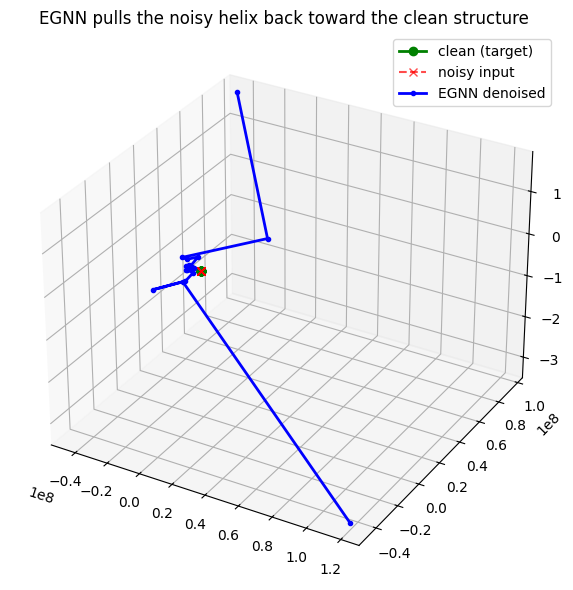

In [11]:
import matplotlib.pyplot as plt  # noqa: F401  (registers 3d projection)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

ex = test_noisy[0]
with torch.no_grad():
    den = egnn(feat, ex)[1]

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")


def trace(c, **kw):
    c = c.detach().numpy()
    ax.plot(c[:, 0], c[:, 1], c[:, 2], **kw)


trace(clean, color="green", marker="o", linewidth=2, label="clean (target)")
trace(ex, color="red", marker="x", linestyle="--", alpha=0.7, label="noisy input")
trace(den, color="blue", marker=".", linewidth=2, label="EGNN denoised")
ax.legend()
ax.set_title("EGNN pulls the noisy helix back toward the clean structure")
plt.tight_layout()
plt.show()